# US equities panel: a neural network on the same flat table, and what an ensemble of them costs

[`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) read the same design matrix: one row
per stock per session, one column per feature, nothing in the representation saying the rows are
ordered in time. They differ in what they can express. A penalized linear model gives each
feature one coefficient, and where several columns carry nearly the same information it can
spread weight across all of them. A tree ensemble can express an interaction - a condition on one
feature evaluated inside a region another feature defines - but it gets there by picking one
column at each split, and among near-duplicate columns which one gets picked is close to
arbitrary.

A neural network on that same table is a third answer. Its first layer is a weighted sum of every
feature, so like the linear model it never has to choose between correlated columns; the
nonlinearity after it lets those sums combine into interactions the linear model cannot write
down. That is the reason to fit one here, rather than a general preference for neural networks:
the two properties that pulled against each other in the previous two notebooks are not obviously
in conflict in this architecture.

**TabM is an ensemble, and the ensemble is the point.** Averaging several independently
initialized networks is a standard way to make a neural fit less erratic, and the ordinary cost
is training that many networks. TabM trains most of one. A two-layer network - the **backbone** -
is shared by every member. Each member owns two small things of its own: a vector carrying one
number per hidden unit, which scales the backbone's output element by element, and its own final
linear layer turning that scaled output into a prediction. The members' predictions are averaged.
What differs between members is therefore one vector and one output layer each, set against a
backbone as wide as the hidden size - which is why adding members grows the model far more slowly
than training that many separate networks would.

**The three declared configurations move both dials at once.** `tabm_s`, `tabm_m` and `tabm_l`
pair a hidden width of 64, 128 and 256 with 4, 8 and 16 members. So this grid is a capacity
ladder rather than an experiment separating width from ensemble size: a difference between two
rungs cannot be attributed to either dial on its own.

**A neural fit has a meaningful state at every epoch**, the way a boosted model has one at every
iteration and a linear fit does not. An **epoch** is one pass over the training rows. Each
configuration here trains for 200 of them and saves its weights every 25, so it produces eight
scoreable models rather than one, and each is registered with its own identity. The count that
matters downstream is configurations times checkpoints - three times eight - not three.

**Learning objectives.** By the end of this notebook you will be able to:

- Describe what a weight-sharing ensemble holds in common between its members and what it keeps
  separate, and say why *k* members cost far less than *k* networks.
- Read the epoch schedule out of a declared configuration and say how many scoreable models the
  run publishes for it.
- Say why a grid that moves width and member count together cannot attribute a difference to
  either one, and what a grid that separated them would have to hold fixed.
- Recognise that a model can predict nearly the same value for every stock on a date, why that
  date then contributes nothing to a ranking measure, and why a run can be registered complete
  and still have scored no dates at all.
- Locate where a configuration and a stopping point are actually chosen in this case study, and
  say why that is not here.

**Book reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives). Chapter 6, Section 6.7
(Search accounting and run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) and [`07_gbm`](07_gbm.ipynb) fitted the two populations this one
sits beside.

**What it writes**: one training run per configuration and one complete validation prediction set
per configuration and epoch checkpoint, in `run_log/registry.db` and under `run_log/training/`
and `run_log/predictions/`, grouped under a named population.
[`15_model_analysis`](15_model_analysis.ipynb) compares that population against the other
families and [`16_backtest`](16_backtest.ipynb) backtests every member and selects on validation
backtest Sharpe. **Selection happens there, not here.**

In [1]:
"""Generate TabM validation predictions through the shared research interface."""

import matplotlib.pyplot as plt
import polars as pl
import yaml

from case_studies.research import (
    candidate_set_supersedes,
    open_study,
    plan_models,
    run_model_population,
    supersedes_for_run,
)
from utils.modeling import load_configs
from utils.paths import get_case_study_dir
from utils.style import FIGSIZE, add_message_title, ml4t_palette, show_with_alt, zero_line

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = ""
CONFIG_NAMES = []
COMMON_OVERRIDES = {}
CONFIG_OVERRIDES = {}
DIAGNOSTIC_CONFIG_NAMES = ["tabm_s"]
POPULATION_NAME = ""
SUPERSEDES_POPULATION = ""
SUPERSEDES_SETS: dict = {}
DEVICE = "cuda"
EXECUTION_TIER = "canonical"
WORKSPACE = ""
PREVIEW_MAX_SYMBOLS = 0
PREVIEW_MAX_FOLDS = 0
PREVIEW_N_EPOCHS = 0
PREVIEW_CHECKPOINT_INTERVAL = 0

## 1. Which configurations, and on which label

The menu at `config/training/{label}.yaml` lists the TabM configurations declared for a label,
and each name resolves to a preset in `case_studies/config/tabm/` holding the full parameter set.
The table below shows the whole menu with a column marking which entries this run selected.

What each setting a run may pass decides:

- **`CONFIG_NAMES`** empty fits the whole declared menu. A list such as `['tabm_s']` fits that
  subset, which is what to do first: at panel scale the full menu is hours, and the point of a
  first pass is to find out whether the plumbing works.
- **`COMMON_OVERRIDES`** changes a model or runner parameter for every selected configuration and
  **`CONFIG_OVERRIDES`** changes one named configuration, taking precedence. An override moves a
  training identity, so an overridden run registers beside the published one rather than
  replacing it.
- **`DIAGNOSTIC_CONFIG_NAMES`** names the configuration [`15_model_analysis`](15_model_analysis.ipynb)
  reads raw predictions for. It is bounded hard: that comparison loads every diagnostic member's
  prediction frame and holds them all while it joins them pairwise, and one frame on this panel
  is over seven million rows and about 225 MB in memory. The frozen set below is the named
  configuration at its last epoch checkpoint - one member for this label and family.
- **`EXECUTION_TIER`** is `canonical` or `preview`. A canonical run fits the whole panel on every
  fold at the published epoch schedule. A preview run has to declare at least one reduction, and
  its results carry that reduction in their identity so they can never be compared against
  canonical ones or reach a holdout decision.

In [3]:
case_dir = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((case_dir / "config" / "setup.yaml").read_text())
label = PRIMARY_LABEL or setup["labels"]["primary"]

published_configs = load_configs(CASE_STUDY_ID, label, family="tabular_dl")
published_names = [str(config["config_name"]) for config in published_configs]
selected_names = list(CONFIG_NAMES) if CONFIG_NAMES else published_names
unknown_names = sorted(set(selected_names) - set(published_names))
unknown_overrides = sorted(set(CONFIG_OVERRIDES) - set(selected_names))
if unknown_names:
    raise ValueError(f"Unknown TabM configurations: {unknown_names}")
if unknown_overrides:
    raise ValueError(f"Overrides supplied for unselected configurations: {unknown_overrides}")
if len(selected_names) != len(set(selected_names)):
    raise ValueError("CONFIG_NAMES contains duplicates")
unknown_diagnostics = sorted(set(DIAGNOSTIC_CONFIG_NAMES) - set(selected_names))
if not DIAGNOSTIC_CONFIG_NAMES or unknown_diagnostics:
    raise ValueError(f"Invalid diagnostic configurations: {unknown_diagnostics}")

menu = pl.DataFrame(
    {
        "config_name": [config["config_name"] for config in published_configs],
        "library": [config["library"] for config in published_configs],
        "published_params": [str(config.get("params") or {}) for config in published_configs],
        "n_epochs": [config.get("n_epochs") for config in published_configs],
        "checkpoint_interval": [config.get("checkpoint_interval") for config in published_configs],
        "selected": [config["config_name"] in selected_names for config in published_configs],
    }
)
menu

config_name,library,published_params,n_epochs,checkpoint_interval,selected
str,str,str,i64,i64,bool
"""tabm_s""","""tabm""","""{'dropout': 0.1, 'hidden_dim':…",200,25,true
"""tabm_m""","""tabm""","""{'dropout': 0.1, 'hidden_dim':…",200,25,true
"""tabm_l""","""tabm""","""{'dropout': 0.1, 'hidden_dim':…",200,25,true


A run that narrows the selection, overrides a parameter or fits on another device produces a
different set of predictions from the one the canonical name stands for. Publishing it under
that name would leave the name meaning two different member sets at two different times, so the
guard below requires such a run to say what to call its own population, and the frozen set names
in Section 6 are withheld from it for the same reason.

In [4]:
is_published_population = (
    EXECUTION_TIER == "canonical"
    and selected_names == published_names
    and not COMMON_OVERRIDES
    and not CONFIG_OVERRIDES
    and DEVICE == "cuda"
)
if EXECUTION_TIER == "canonical" and not is_published_population and not POPULATION_NAME:
    raise ValueError(
        "this run narrows or overrides what the menu declares, so it cannot publish the canonical "
        "population; pass POPULATION_NAME to give it its own"
    )

Both tiers resolve the study through `open_study`. It reads the labels and features in place
and redirects only writes, so a preview run scores the same inputs a canonical one does and
cannot publish over it. A preview must be given a workspace to write into; a canonical run
leaves `WORKSPACE` empty and regenerates the case study's own artifacts in place.

In [5]:
preview_reductions = {}
if PREVIEW_MAX_SYMBOLS:
    preview_reductions["max_symbols"] = int(PREVIEW_MAX_SYMBOLS)
if PREVIEW_MAX_FOLDS:
    preview_reductions["folds"] = list(range(int(PREVIEW_MAX_FOLDS)))
if PREVIEW_N_EPOCHS:
    preview_reductions["n_epochs"] = int(PREVIEW_N_EPOCHS)
if PREVIEW_CHECKPOINT_INTERVAL:
    preview_reductions["checkpoint_interval"] = int(PREVIEW_CHECKPOINT_INTERVAL)

study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 2. Binding the declarations to the data

A **request** is one configuration bound to one label and one execution tier, with its overrides
resolved. It is what the planner reads, and it holds no data - so the table below can be
inspected before anything is loaded.

In [6]:
requests = []
for config_name in selected_names:
    overrides = {
        "device": DEVICE,
        **COMMON_OVERRIDES,
        **dict(CONFIG_OVERRIDES.get(config_name, {})),
    }
    requests.append(
        study.model(
            family="tabular_dl",
            label=label,
            config_name=config_name,
            overrides=overrides,
            execution_tier=EXECUTION_TIER,
            preview_reductions=preview_reductions,
            notebook="08_tabular_dl",
        )
    )
requests = tuple(requests)

request_table = pl.DataFrame(
    {
        "family": [request.family for request in requests],
        "label": [request.label for request in requests],
        "config_name": [request.config_name for request in requests],
        "overrides": [str(request.overrides) for request in requests],
        "execution_tier": [request.execution_tier.value for request in requests],
        "preview_reductions": [str(request.preview_reductions) for request in requests],
    }
)
request_table

family,label,config_name,overrides,execution_tier,preview_reductions
str,str,str,str,str,str
"""tabular_dl""","""fwd_ret_1d""","""tabm_s""","""{'device': 'cuda'}""","""canonical""","""{}"""
"""tabular_dl""","""fwd_ret_1d""","""tabm_m""","""{'device': 'cuda'}""","""canonical""","""{}"""
"""tabular_dl""","""fwd_ret_1d""","""tabm_l""","""{'device': 'cuda'}""","""canonical""","""{}"""


## 3. Planning, then fitting

**Planning works out every identity before any fitting starts.** Each configuration-and-epoch
pair gets its training and prediction hash from the declarations and the fold boundaries alone,
and the list of them is written down as a **population**: a named, immutable membership that the
run then has to fill completely. Declaring the membership first is what makes the downstream
comparison well defined, because a population that came out short would otherwise look like a
smaller experiment rather than a failed one.

The plan walks folds on the outside and configurations on the inside, so one prepared fold is
resident at a time however many configurations were declared - which on a three-thousand-name
panel across sixteen ten-year training windows is the difference between fitting and running out
of memory. Every declared epoch saves its preprocessing, its weights and its predictions before
the fold is released, so an interrupted run resumes from the last completed fold instead of
starting over.

In [7]:
plan = plan_models(study, requests=requests)

planned_population = pl.DataFrame(
    {
        "family": [member.family for member in plan.members],
        "config_name": [member.config_name for member in plan.members],
        "checkpoint_kind": [member.checkpoint_kind for member in plan.members],
        "checkpoint_value": [member.checkpoint_value for member in plan.members],
        "training_hash": [member.training_hash for member in plan.members],
        "prediction_hash": [member.prediction_hash for member in plan.members],
    }
)
planned_population

family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash
str,str,str,i64,str,str
"""tabular_dl""","""tabm_s""","""epoch""",25,"""89a1a28f3367""","""a19c128ccbfc"""
"""tabular_dl""","""tabm_s""","""epoch""",50,"""89a1a28f3367""","""b7f35904dcde"""
"""tabular_dl""","""tabm_s""","""epoch""",75,"""89a1a28f3367""","""a3e2db2402d6"""
"""tabular_dl""","""tabm_s""","""epoch""",100,"""89a1a28f3367""","""a1c9bfed75cf"""
"""tabular_dl""","""tabm_s""","""epoch""",125,"""89a1a28f3367""","""1fa6f2556fdf"""
…,…,…,…,…,…
"""tabular_dl""","""tabm_l""","""epoch""",100,"""2c05641b961e""","""dccb034143d3"""
"""tabular_dl""","""tabm_l""","""epoch""",125,"""2c05641b961e""","""6baed0817974"""
"""tabular_dl""","""tabm_l""","""epoch""",150,"""2c05641b961e""","""4d2b3cbec5cd"""


`run_model_population` takes the plan, writes the population down, fits every member and then
checks that what came out is what was declared. The same call serves both tiers: a canonical run
registers an immutable population that the later notebooks bind to, and a preview run gets a
declaration that is verified and then discarded with its workspace, so no notebook here has to
branch on the tier to decide what to publish.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is a set of
prediction identities, so anything that moves a training identity - a changed preset as much as a
changed menu - produces a different population under the same name, and the registry refuses to
write it without being told which snapshot it supersedes. Leaving it empty is right for a first
run and for a reader's clean clone, and `supersedes_for_run` withholds a declared hash wherever
offering it would be refused.

In [8]:
population_name = POPULATION_NAME or "us-equities-tabular-dl-checkpoints-v1"
execution, official_population = run_model_population(
    study,
    plan,
    population_name=population_name,
    supersedes=supersedes_for_run(
        study,
        population_name=population_name,
        declared=SUPERSEDES_POPULATION,
        execution_tier=EXECUTION_TIER,
    ),
)

print(f"population {official_population.name}: {len(official_population.members)} prediction sets")

Preparing and releasing folds...


  Fold 0: train=1,590,932  val=268,603


      epoch  25/200: loss=0.000768, IC=+0.0109


      epoch  50/200: loss=0.000759, IC=+0.0127


      epoch  75/200: loss=0.000750, IC=+0.0105


...

    → best_epoch=25, IC=+0.0158 (14056.5s)


    → best_epoch=25, IC=+0.0156 (17776.0s)


    → best_epoch=25, IC=+0.0176 (22308.9s)



  Best: 2c05641b961e @ epoch 25 (IC=+0.0176)


population us-equities-tabular-dl-checkpoints-v1: 24 prediction sets


## 4. What was actually fitted

A configuration names a preset, and a preset leaves most settings to a default. The table below
is the fully resolved specification the runner used - every feature count, fold count, device,
epoch schedule and batch size, including the defaults nothing above restated. This is the record
a reader checks a result against, and it is what the training hash is computed from.

In [9]:
resolved_rows = []
for run in execution.runs:
    spec = run.training.spec()
    computation = spec["computation"]
    model = computation["model"]
    resolved_rows.append(
        {
            "config_name": spec["config_name"],
            "task": computation["task"]["type"],
            "features": len(computation["feature_names"]),
            "folds": computation["expected_prediction_keys"]["n_folds"],
            "device": computation["numerics"]["device"],
            "n_epochs": model["params"]["n_epochs"],
            "batch_size": model["params"]["batch_size"],
            "checkpoints": [item["value"] for item in computation["checkpoint_schedule"]],
            "training_hash": run.training.hash,
        }
    )

resolved_table = pl.DataFrame(resolved_rows).sort("config_name")
resolved_table

config_name,task,features,folds,device,n_epochs,batch_size,checkpoints,training_hash
str,str,i64,i64,str,i64,i64,list[i64],str
"""tabm_l""","""regression""",71,16,"""cuda""",200,4096,"[25, 50, … 200]","""2c05641b961e"""
"""tabm_m""","""regression""",71,16,"""cuda""",200,4096,"[25, 50, … 200]","""2fa2b43c4aa8"""
"""tabm_s""","""regression""",71,16,"""cuda""",200,4096,"[25, 50, … 200]","""89a1a28f3367"""


## 5. What came out

One row per configuration and epoch checkpoint. Each is one complete set of validation
predictions, with the hash of the training run that produced it and the hash of the predictions
themselves, so any row can be traced back to the exact fitted state behind it.

`ic_mean` is the **information coefficient**: on each validation date, rank the stocks by the
model's prediction, rank them by the return they went on to earn, correlate the two rankings, and
average that daily correlation over the validation period. It measures whether predictions order
the cross-section correctly, and nothing about what a strategy trading them would earn.

In [10]:
catalog_columns = [
    "family",
    "config_name",
    "label",
    "split",
    "checkpoint_kind",
    "checkpoint_value",
    "execution_tier",
    "complete",
    "ic_mean",
    "training_hash",
    "prediction_hash",
]
catalog_rows = execution.catalog_rows.select(
    column for column in catalog_columns if column in execution.catalog_rows.columns
).sort("config_name", "checkpoint_value", "prediction_hash")
catalog_rows

family,config_name,label,split,checkpoint_kind,checkpoint_value,execution_tier,complete,ic_mean,training_hash,prediction_hash
str,str,str,str,str,i64,str,bool,f64,str,str
"""tabular_dl""","""tabm_l""","""fwd_ret_1d""","""validation""","""epoch""",25,"""canonical""",true,0.017552,"""2c05641b961e""","""c1a05aabd5e1"""
"""tabular_dl""","""tabm_l""","""fwd_ret_1d""","""validation""","""epoch""",50,"""canonical""",true,0.016131,"""2c05641b961e""","""8701c9f69381"""
"""tabular_dl""","""tabm_l""","""fwd_ret_1d""","""validation""","""epoch""",75,"""canonical""",true,0.013979,"""2c05641b961e""","""6e573058c2fb"""
"""tabular_dl""","""tabm_l""","""fwd_ret_1d""","""validation""","""epoch""",100,"""canonical""",true,0.013634,"""2c05641b961e""","""dccb034143d3"""
"""tabular_dl""","""tabm_l""","""fwd_ret_1d""","""validation""","""epoch""",125,"""canonical""",true,0.013897,"""2c05641b961e""","""6baed0817974"""
…,…,…,…,…,…,…,…,…,…,…
"""tabular_dl""","""tabm_s""","""fwd_ret_1d""","""validation""","""epoch""",100,"""canonical""",true,0.012281,"""89a1a28f3367""","""a1c9bfed75cf"""
"""tabular_dl""","""tabm_s""","""fwd_ret_1d""","""validation""","""epoch""",125,"""canonical""",true,0.012902,"""89a1a28f3367""","""1fa6f2556fdf"""
"""tabular_dl""","""tabm_s""","""fwd_ret_1d""","""validation""","""epoch""",150,"""canonical""",true,0.012739,"""89a1a28f3367""","""e0f44869757c"""


A prediction set can be registered complete and still have scored no dates. Cross-sectional
information coefficient needs a minimum number of names quoted on a date before the ranking on
that date means anything, so a universe whose stocks do not overlap in time yields no scorable
dates and a null IC at every checkpoint while every coverage check passes. That is a run which
reports nothing and looks successful, so it is asserted on rather than left to be noticed.

In [11]:
scored = execution.catalog_rows.select("config_name", "checkpoint_value", "ic_mean", "ic_n_days")
unscored = scored.filter(pl.col("ic_n_days").is_null() | (pl.col("ic_n_days") <= 0))
if not unscored.is_empty():
    raise RuntimeError(f"prediction sets scored no dates: {unscored.to_dicts()}")
scored

config_name,checkpoint_value,ic_mean,ic_n_days
str,i64,f64,f64
"""tabm_l""",175,0.01321,4031.0
"""tabm_m""",200,0.011137,4031.0
"""tabm_s""",125,0.012902,4031.0
"""tabm_l""",200,0.013147,4031.0
"""tabm_m""",25,0.015597,4031.0
…,…,…,…
"""tabm_l""",100,0.013634,4031.0
"""tabm_s""",150,0.012739,4031.0
"""tabm_m""",100,0.011913,4031.0


### Where more training stopped helping

Each line traces one configuration's validation information coefficient as epochs are added to
it. This is the figure the checkpoint dimension exists to produce, and it separates two things a
single end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training windows at the expense of the validation folds. That is the evidence about whether the capacity
ladder outruns what this panel supports, and it is the only place the three rungs can be
compared at equal training length.
A line that wanders around zero without trend never had anything to learn, and its highest point
is wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why
the curve rather than the maximum is what to read.

Nothing here selects a checkpoint. Every one of them is registered as its own candidate, and
which one a strategy would use is decided by validation backtest Sharpe in
[`16_backtest`](16_backtest.ipynb).

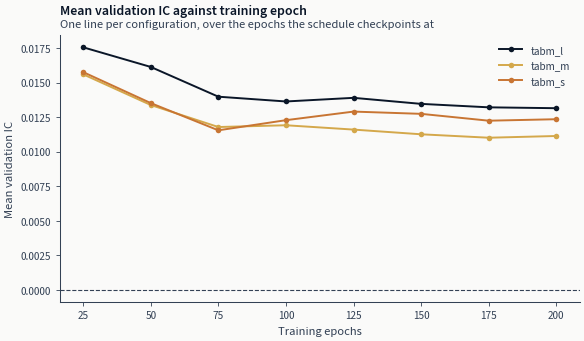

In [12]:
curves = scored.sort("config_name", "checkpoint_value")
config_names = curves.get_column("config_name").unique(maintain_order=True).to_list()
# `ml4t_palette` returns a list of that many colours, so it is called once and indexed.
palette = ml4t_palette(len(config_names), categorical=True)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for index, config_name in enumerate(config_names):
    series = curves.filter(pl.col("config_name") == config_name)
    ax.plot(
        series.get_column("checkpoint_value"),
        series.get_column("ic_mean"),
        marker="o",
        markersize=4,
        lw=1.4,
        color=palette[index],
        label=config_name,
    )
zero_line(ax)
ax.set_xlabel("Training epochs")
ax.set_ylabel("Mean validation IC")
ax.legend(fontsize=8, frameon=False)
add_message_title(
    ax,
    "Mean validation IC against training epoch",
    subtitle="One line per configuration, over the epochs the schedule checkpoints at",
)
# The alt text counts rather than asserts: whether a curve turns over is the question the figure
# exists to answer, and a line described as peaking when it does not is a claim the data refutes.
_peaks = (
    curves.group_by("config_name")
    .agg(
        peak=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first=pl.col("checkpoint_value").min(),
        last=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        interior=pl.col("peak").is_between(pl.col("first"), pl.col("last"), closed="none")
    )
)
_n_interior = int(_peaks.get_column("interior").sum())
show_with_alt(
    fig,
    "A line chart of mean validation information coefficient against training epoch, one line per "
    "configuration, with a dashed line at zero. Counted from the underlying frame, "
    f"{_n_interior} of {_peaks.height} configurations reach their highest information coefficient "
    "at an epoch that is neither the first nor the last, which is what an interior optimum looks "
    "like on this chart.",
)

In [13]:
coverage_rows = []
for run in execution.runs:
    if not run.training.complete:
        raise RuntimeError(f"Incomplete training result: {run.training.hash}")
    for prediction in run.predictions:
        record = prediction.registry_record()
        coverage = prediction.coverage()
        if not prediction.complete or coverage is None or coverage["status"] != "complete":
            raise RuntimeError(f"Incomplete prediction result: {prediction.hash}")
        coverage_rows.append(
            {
                "config_name": run.training.spec()["config_name"],
                "checkpoint": record["checkpoint_value"],
                "training_hash": run.training.hash,
                "prediction_hash": prediction.hash,
                "coverage_status": coverage["status"],
                "expected_rows": coverage["n_expected"],
                "actual_rows": coverage["n_actual"],
                "training_artifacts": len(run.training.artifacts()),
                "prediction_artifacts": len(prediction.artifacts()),
            }
        )

coverage_table = pl.DataFrame(coverage_rows).sort("config_name", "checkpoint")
coverage_table

config_name,checkpoint,training_hash,prediction_hash,coverage_status,expected_rows,actual_rows,training_artifacts,prediction_artifacts
str,i64,str,str,str,i64,i64,i64,i64
"""tabm_l""",25,"""2c05641b961e""","""c1a05aabd5e1""","""complete""",7170323,7170323,311,1
"""tabm_l""",50,"""2c05641b961e""","""8701c9f69381""","""complete""",7170323,7170323,311,1
"""tabm_l""",75,"""2c05641b961e""","""6e573058c2fb""","""complete""",7170323,7170323,311,1
"""tabm_l""",100,"""2c05641b961e""","""dccb034143d3""","""complete""",7170323,7170323,311,1
"""tabm_l""",125,"""2c05641b961e""","""6baed0817974""","""complete""",7170323,7170323,311,1
…,…,…,…,…,…,…,…,…
"""tabm_s""",100,"""89a1a28f3367""","""a1c9bfed75cf""","""complete""",7170323,7170323,311,1
"""tabm_s""",125,"""89a1a28f3367""","""1fa6f2556fdf""","""complete""",7170323,7170323,311,1
"""tabm_s""",150,"""89a1a28f3367""","""e0f44869757c""","""complete""",7170323,7170323,311,1


In [14]:
execution_diagnostics = pl.DataFrame(execution.diagnostics)
execution_diagnostics

status,training_hash,execution_order,compatibility_group,compatibility_group_size,fitted_folds,group_size,reused,reused_folds,base_fold_preparations,base_fold_preparation_s,preparation_fraction,candidate_fit_s,disk_fold_cache
str,str,str,str,i64,list[i64],i64,bool,list[null],i64,f64,f64,f64,bool
"""completed""","""89a1a28f3367""","""fold_major""","""386ad902f18a""",3,"[0, 1, … 15]",3,false,[],16,465.235715,0.00852,14056.496184,false
"""completed""","""2fa2b43c4aa8""","""fold_major""","""386ad902f18a""",3,"[0, 1, … 15]",3,false,[],16,465.235715,0.00852,17776.049632,false
"""completed""","""2c05641b961e""","""fold_major""","""386ad902f18a""",3,"[0, 1, … 15]",3,false,[],16,465.235715,0.00852,22308.859125,false


## 6. Naming the sets the later notebooks open

`16_backtest` never opens the population. It opens **named prediction sets**, one per label and
family, because a comparison is only meaningful within one label's protocol.
`15_model_analysis` opens both - the population, to confirm the run filled every member it
promised, and the named sets, to make the comparison. Freezing is what creates those names.

Only an unnarrowed canonical run publishes them, and for the same reason a narrowed run may not
publish the canonical population: a name must not mean two different member sets at two different
times. A run that overrides a parameter, selects a subset, or runs on a device other than the
declared one keeps its rows and publishes no name.

In [15]:
set_rows = []
if is_published_population:
    label_name = label.replace("_", "-")
    full_set_name = f"us-equities-{label_name}-tabular-dl-v1"
    full_set = study.predictions.freeze(
        execution.catalog_rows,
        name=full_set_name,
        supersedes=candidate_set_supersedes(
            study, name=full_set_name, declared=SUPERSEDES_SETS.get(full_set_name, "")
        ),
    )
    diagnostic_rows = execution.catalog_rows.filter(
        pl.col("config_name").is_in(DIAGNOSTIC_CONFIG_NAMES)
        # `.fill_null(True)` covers a family that publishes no checkpoint value at all, where the
        # comparison is null rather than false and would otherwise empty the frame.
        & (
            pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("config_name")
        ).fill_null(True)
    )
    diagnostic_set_name = f"us-equities-{label_name}-tabular-dl-diagnostics-v1"
    diagnostic_set = study.predictions.freeze(
        diagnostic_rows,
        name=diagnostic_set_name,
        supersedes=candidate_set_supersedes(
            study, name=diagnostic_set_name, declared=SUPERSEDES_SETS.get(diagnostic_set_name, "")
        ),
    )
    set_rows = [
        {
            "role": "backtest population",
            "set_name": full_set.name,
            "members": len(full_set.members),
        },
        {
            "role": "bounded diagnostics",
            "set_name": diagnostic_set.name,
            "members": len(diagnostic_set.members),
        },
    ]
compatible_sets = pl.DataFrame(
    set_rows,
    schema={"role": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

role,set_name,members
str,str,i64
"""backtest population""","""us-equities-fwd-ret-1d-tabular…",24
"""bounded diagnostics""","""us-equities-fwd-ret-1d-tabular…",1


`15_model_analysis.py` reopens the named compatible and diagnostic sets. `16_backtest.py` passes
every full-set catalog row directly to the shared backtest runner. Model metrics do not choose a
configuration or checkpoint.

## What to notice

**A checkpoint is part of a configuration, not a detail of how it was fitted.** Saving weights
every 25 epochs turns three configurations into twenty-four scoreable models. Treating that as
three candidates while quietly keeping each one's best epoch would report the maximum of eight
numbers as though it were one, which is why every checkpoint is registered separately and
compared as its own candidate.

**A complete run is not the same as a scored one.** Cross-sectional information coefficient needs
a minimum number of names on a date before that date can be ranked at all. A universe whose
stocks do not overlap in time can satisfy every coverage check and still score zero dates,
leaving a null IC under a status that reads complete. The assertion above refuses that rather
than reporting it.

**This grid measures capacity and nothing finer.** Width and member count move together across
the three rungs, so a difference between them is a difference in capacity as a whole. Separating
the two would need a grid holding one fixed while the other varies, which this case study does
not declare.

**Known limitations.** The features are the same point-in-time columns the previous two
notebooks read, so anything absent from them is absent here too; the architecture finds
interactions among the columns it is given and does not create information. Validation results
say how the fits ranked on folds that have been read many times over by the time a case study
reaches this notebook, and say nothing about behaviour under a changed feature distribution.

**Next**: [`09_dl_nlinear`](09_dl_nlinear.ipynb) drops the flat-table representation and gives a
model the ordered window instead.